# News Articles Analysis: Zohran Mamdani 2025 NYC Mayoral Election

This notebook visualizes news articles about Zohran Mamdani during the 2025 New York City mayoral election campaign.

## Data Overview
- Articles collected from multiple news sources
- Time period: September 2025 - November 2025
- Categories: Endorsements, Civil Policy, Controversy, Campaign, Social Cause, Governance
- Sentiment: Positive, Negative, Neutral


In [1]:
pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install seaborn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install pandas


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install numpy


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import numpy as np

# Set style for better-looking plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Configure display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)

In [6]:
# Load the data
df = pd.read_csv('articles_annotated.csv')

# Parse the published_at date (format: M/D/YYYY)
df['published_at'] = pd.to_datetime(df['published_at'], format='%m/%d/%Y', errors='coerce')

# Extract date components
df['date'] = df['published_at'].dt.date
df['year'] = df['published_at'].dt.year
df['month'] = df['published_at'].dt.month
df['day'] = df['published_at'].dt.day
df['week'] = df['published_at'].dt.isocalendar().week
df['day_of_week'] = df['published_at'].dt.day_name()

# Clean category names (remove quotes if present)
df['categories'] = df['categories'].str.strip().str.replace('"', '', regex=False)

# Create period column (Pre-Election vs Post-Election)
# Election date: November 5, 2025
election_date = pd.Timestamp('2025-11-05')
df['period'] = df['published_at'].apply(lambda x: 'Post-Election' if x > election_date else 'Pre-Election')

# Display basic info
print(f"Total articles: {len(df)}")
print(f"Date range: {df['published_at'].min()} to {df['published_at'].max()}")
print(f"\nCategories distribution:")
print(df['categories'].value_counts())
print(f"\nSentiment distribution:")
print(df['sentiment'].value_counts())
print(f"\nFirst few rows:")
df.head()


Total articles: 810
Date range: NaT to NaT

Categories distribution:
categories
Campaign        307
Governance      232
Controversy     117
Endorsements     59
Civil Policy     50
Social Cause     45
Name: count, dtype: int64

Sentiment distribution:
sentiment
Neutral     387
Negative    270
Positive    153
Name: count, dtype: int64

First few rows:


,title,description,url,published_at,source,categories,sentiment,political_orientation,date,year,month,day,week,day_of_week,period
0,Zohran Mamdani bizarrely ghosted by Bronx boro...,NYC mayoral frontrunner and unabashed socialis...,https://nypost.com/2025/09/02/us-news/zohran-m...,NaT,New York Post,Controversy,Negative,right,NaT,NaN,NaN,NaN,<NA>,NaN,Pre-Election
1,Ex-NYC mayor endorses Zohran Mamdani for City ...,"""We need him because in his heart and in his b...",https://nypost.com/2025/09/02/us-news/ex-nyc-m...,NaT,New York Post,Endorsements,Positive,right,NaT,NaN,NaN,NaN,<NA>,NaN,Pre-Election
2,"Mamdani, AOC and other DSA members should leav...",Democratic Socialist of America members who in...,https://nypost.com/2025/09/02/us-news/mamdani-...,NaT,New York Post,Controversy,Negative,right,NaT,NaN,NaN,NaN,<NA>,NaN,Pre-Election
3,Ex-Mayor de Blasio touts socialist Mamdani as ...,Former New York City Mayor Bill de Blasio endo...,https://www.foxnews.com/politics/ex-mayor-de-b...,NaT,Fox News,Endorsements,Positive,right,NaT,NaN,NaN,NaN,<NA>,NaN,Pre-Election
4,REPORT: Zohran Mamdani’s Mother Revealed To Al...,'They are buying somebody who is willing to be...,https://dailycaller.com/2025/09/02/zohran-mamd...,NaT,The Daily Caller,Controversy,Negative,right,NaT,NaN,NaN,NaN,<NA>,NaN,Pre-Election


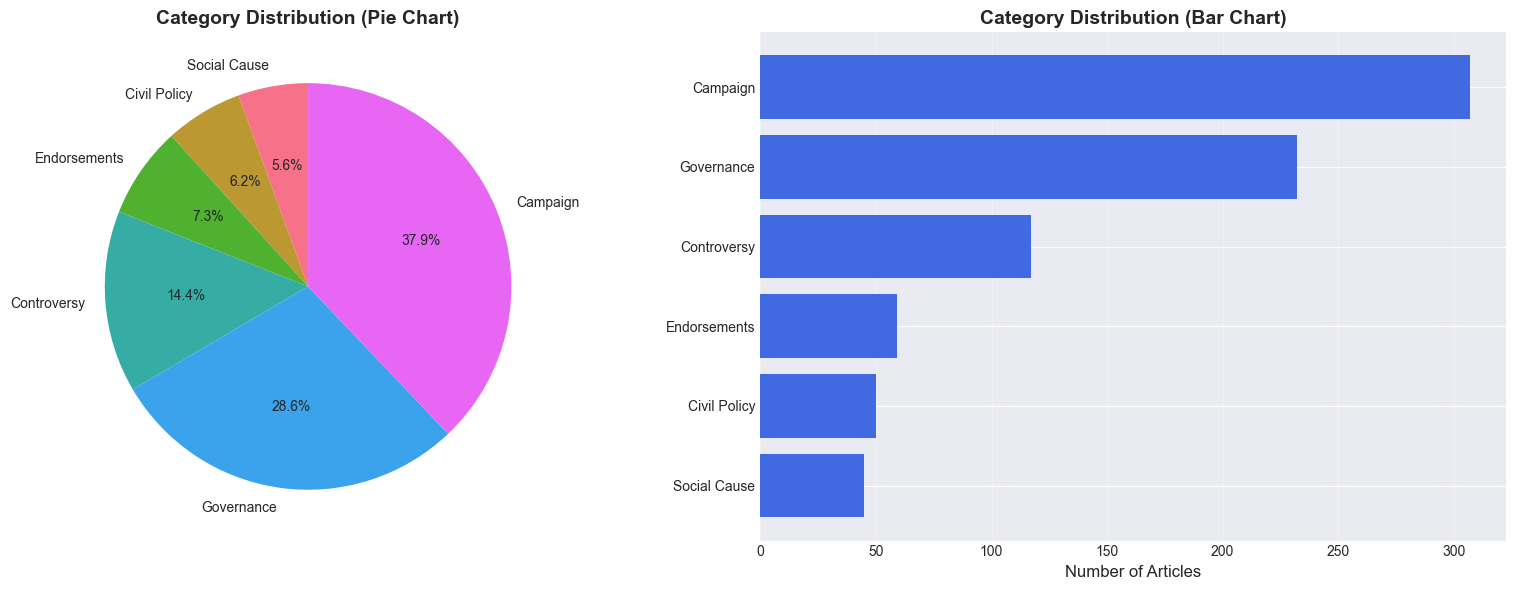

Category breakdown:
  Social Cause: 45 (5.6%)
  Civil Policy: 50 (6.2%)
  Endorsements: 59 (7.3%)
  Controversy: 117 (14.4%)
  Governance: 232 (28.6%)
  Campaign: 307 (37.9%)


In [7]:
# Category counts
category_counts = df['categories'].value_counts()

category_counts = category_counts.sort_values(ascending=True)

# Create pie chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
colors = sns.color_palette("husl", len(category_counts))
ax1.pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%', 
        startangle=90, colors=colors, textprops={'fontsize': 10})
ax1.set_title('Category Distribution (Pie Chart)', fontsize=14, fontweight='bold')

# Bar chart
ax2.barh(category_counts.index, category_counts.values, color='royalblue')
ax2.set_xlabel('Number of Articles', fontsize=12)
ax2.set_title('Category Distribution (Bar Chart)', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("Category breakdown:")
for cat, count in category_counts.items():
    print(f"  {cat}: {count} ({count/len(df)*100:.1f}%)")


## 3. Sentiment Distribution


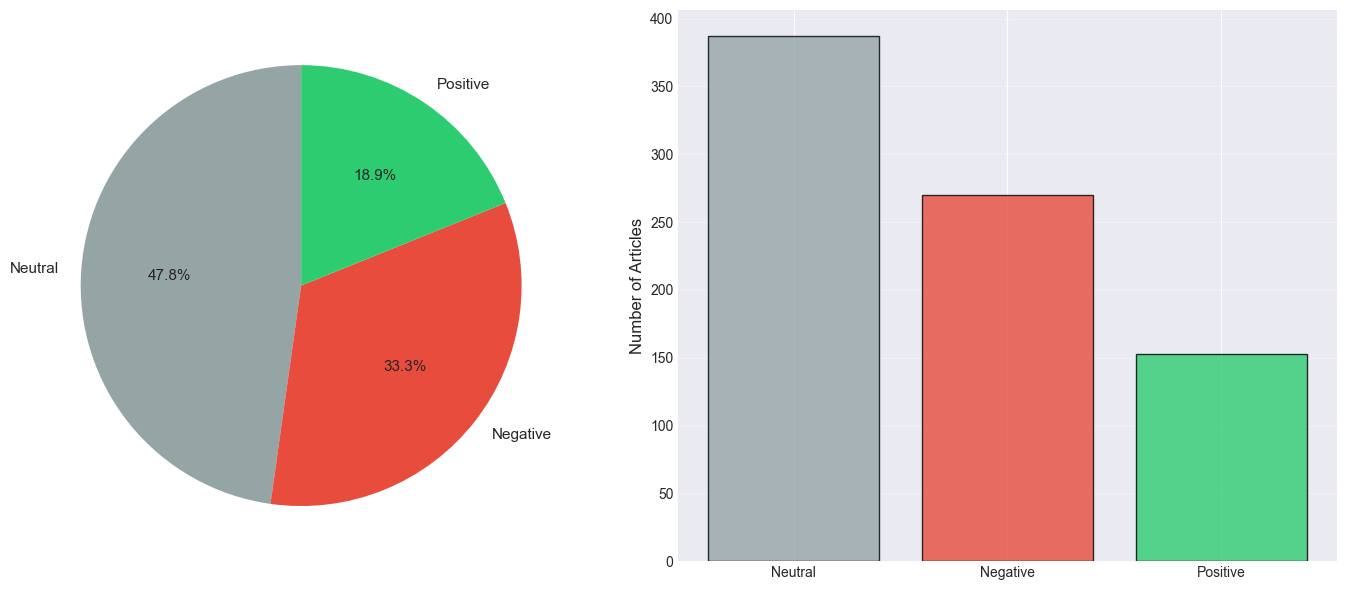

Sentiment breakdown:
  Neutral: 387 (47.8%)
  Negative: 270 (33.3%)
  Positive: 153 (18.9%)


In [8]:
# Sentiment counts
sentiment_counts = df['sentiment'].value_counts()

# Create visualizations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart with custom colors
sentiment_colors = {'Positive': '#2ecc71', 'Negative': '#e74c3c', 'Neutral': '#95a5a6'}
colors_list = [sentiment_colors.get(s, '#3498db') for s in sentiment_counts.index]
ax1.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
        startangle=90, colors=colors_list, textprops={'fontsize': 11})

# Bar chart
ax2.bar(sentiment_counts.index, sentiment_counts.values, color=colors_list, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Number of Articles', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("Sentiment breakdown:")
for sent, count in sentiment_counts.items():
    print(f"  {sent}: {count} ({count/len(df)*100:.1f}%)")


## 7. Category vs Sentiment Heatmap


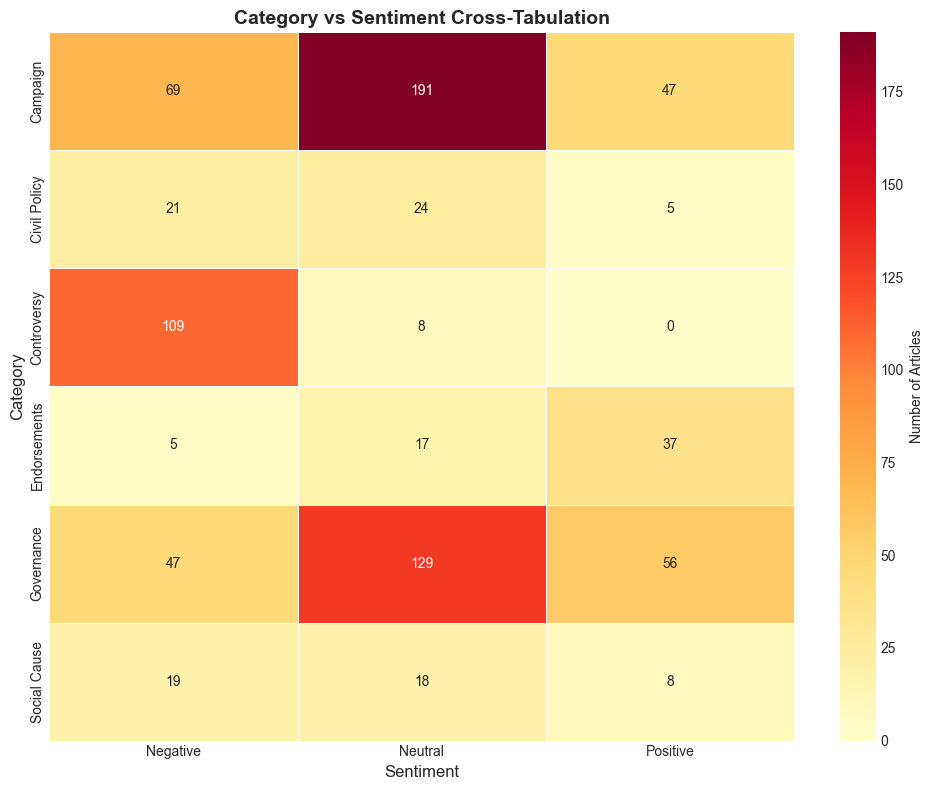

Category-Sentiment breakdown:
sentiment     Negative  Neutral  Positive
categories                               
Campaign            69      191        47
Civil Policy        21       24         5
Controversy        109        8         0
Endorsements         5       17        37
Governance          47      129        56
Social Cause        19       18         8


In [9]:
# Create cross-tabulation
category_sentiment = pd.crosstab(df['categories'], df['sentiment'])

# Create heatmap
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(category_sentiment, annot=True, fmt='d', cmap='YlOrRd', ax=ax, 
            cbar_kws={'label': 'Number of Articles'}, linewidths=0.5)
ax.set_xlabel('Sentiment', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
ax.set_title('Category vs Sentiment Cross-Tabulation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Category-Sentiment breakdown:")
print(category_sentiment)


## 8. Sentiment by Category (Percentage)


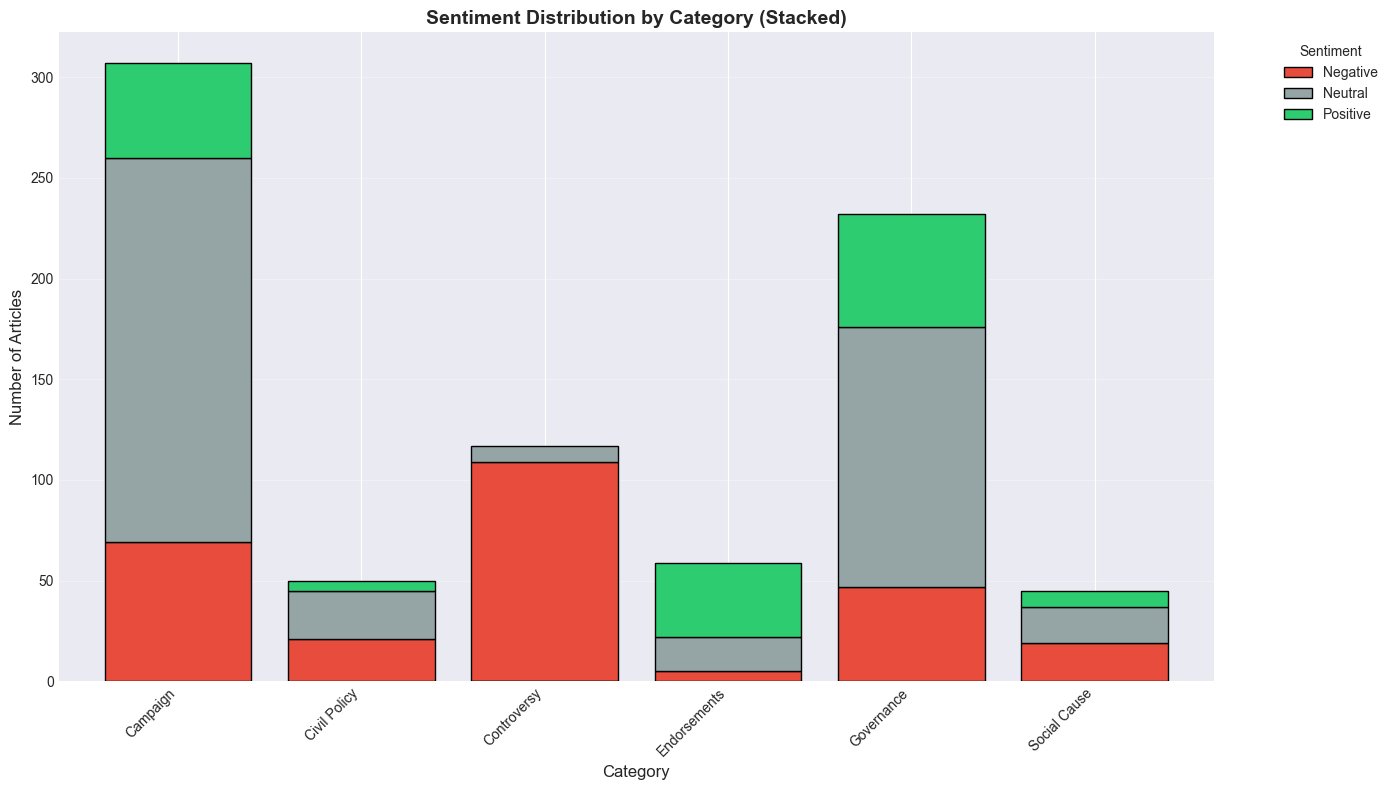

In [10]:
# Sentiment by Category (Bar Chart)
if 'categories' in df.columns and 'sentiment' in df.columns:
    # Create crosstab: categories × sentiment
    category_sentiment = pd.crosstab(df['categories'], df['sentiment'])
    
    # Color scheme for sentiments
    sentiment_colors = {
        'Positive': '#2ecc71',  # Green
        'Negative': '#e74c3c',  # Red
        'Neutral': '#95a5a6'    # Gray
    }
    

    # Also create a stacked bar chart version
    fig, ax = plt.subplots(figsize=(14, 8))
    category_sentiment.plot(kind='bar', stacked=True, ax=ax, 
                           color=[sentiment_colors.get(s, '#3498db') for s in category_sentiment.columns],
                           width=0.8, edgecolor='black')
    ax.set_xlabel('Category', fontsize=12)
    ax.set_ylabel('Number of Articles', fontsize=12)
    ax.set_title('Sentiment Distribution by Category (Stacked)', fontsize=14, fontweight='bold')
    ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

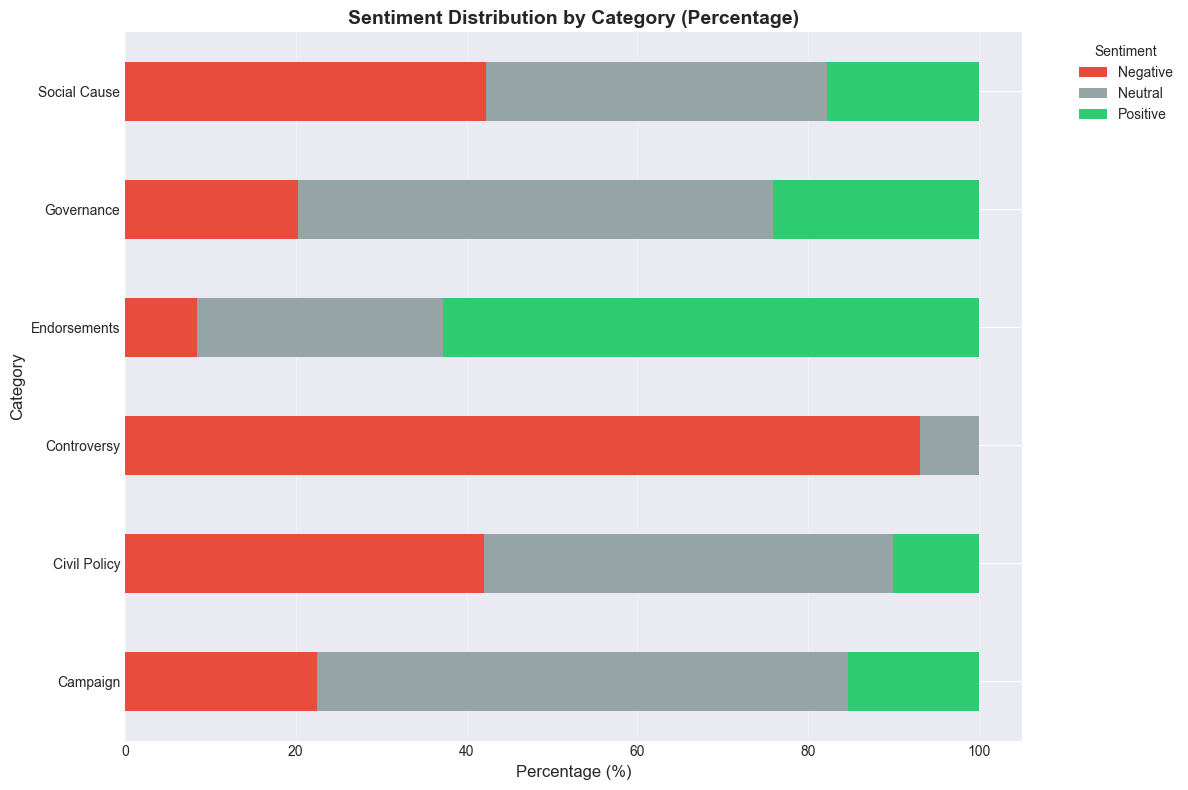

In [11]:
# Calculate percentages
category_sentiment_pct = category_sentiment.div(category_sentiment.sum(axis=1), axis=0) * 100

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(12, 8))
category_sentiment_pct.plot(kind='barh', stacked=True, ax=ax, 
                            color=[sentiment_colors.get(s, '#3498db') for s in category_sentiment_pct.columns])
ax.set_xlabel('Percentage (%)', fontsize=12)
ax.set_ylabel('Category', fontsize=12)
ax.set_title('Sentiment Distribution by Category (Percentage)', fontsize=14, fontweight='bold')
ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()


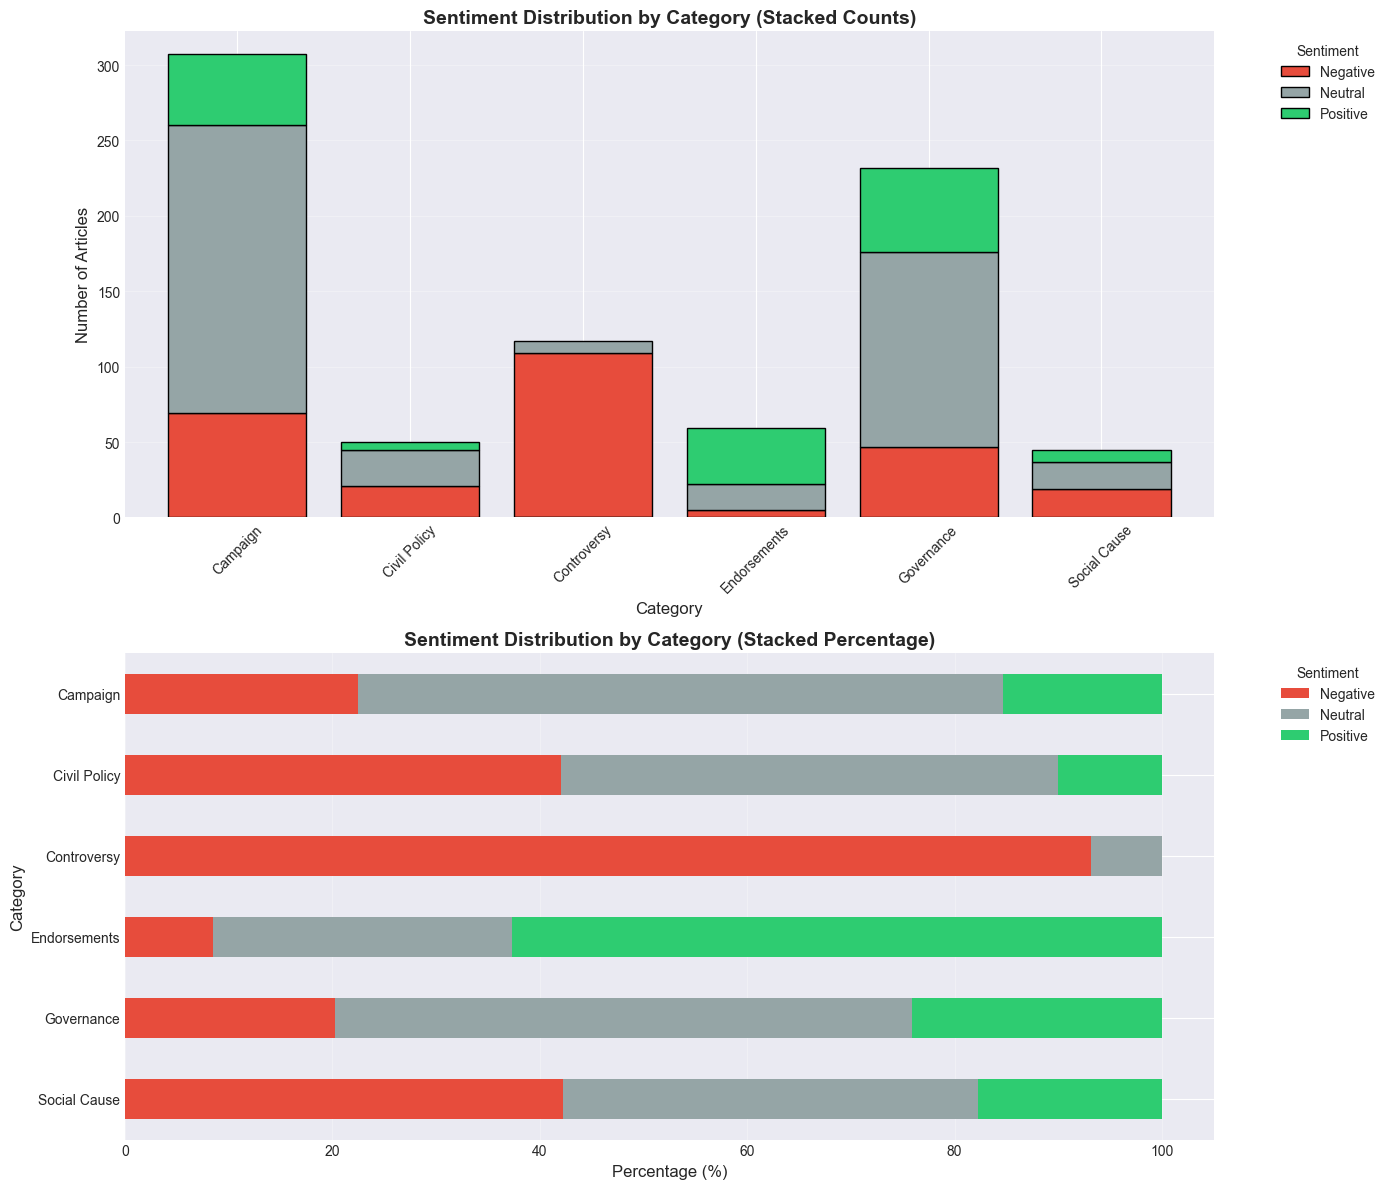

In [31]:
if 'categories' in df.columns and 'sentiment' in df.columns:
    # 1. Create crosstab for counts: categories × sentiment
    category_sentiment = pd.crosstab(df['categories'], df['sentiment'])

    # 2. Calculate percentages
    category_sentiment_pct = category_sentiment.div(category_sentiment.sum(axis=1), axis=0) * 100

    # 3. Color scheme for sentiments (Consistent across both charts)
    sentiment_colors = {
        'Positive': '#2ecc71',  # Green
        'Negative': '#e74c3c',  # Red
        'Neutral': '#95a5a6'    # Gray
    }
    
    # Map colors to the columns based on the sentiment order in the crosstab
    colors = [sentiment_colors.get(s, '#3498db') for s in category_sentiment.columns]

    # Create the figure and two subplots (2 rows, 1 column)
    fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(14, 12)) # Adjust size for stacked vertical layout
    plt.subplots_adjust(hspace=0.4) # Add space between subplots

    # --- Plot 1: Stacked Bar Chart (Counts) ---
    ax1 = axes[0]
    category_sentiment.plot(kind='bar', stacked=True, ax=ax1, 
                           color=colors,
                           width=0.8, edgecolor='black')
    
    ax1.set_xlabel('Category', fontsize=12)
    ax1.set_ylabel('Number of Articles', fontsize=12)
    ax1.set_title('Sentiment Distribution by Category (Stacked Counts)', fontsize=14, fontweight='bold')
    ax1.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.grid(True, alpha=0.3, axis='y')
    ax1.tick_params(axis='x', rotation=45) # Rotate X-axis labels for readability

    # --- Plot 2: Stacked Horizontal Bar Chart (Percentage) ---
    ax2 = axes[1]
    # Note: Using barh (horizontal) for percentages often works well for comparisons
    category_sentiment_pct.iloc[::-1].plot(kind='barh', stacked=True, ax=ax2, 
                            color=colors)
    
    ax2.set_xlabel('Percentage (%)', fontsize=12)
    ax2.set_ylabel('Category', fontsize=12)
    ax2.set_title('Sentiment Distribution by Category (Stacked Percentage)', fontsize=14, fontweight='bold')
    # Since the colors are the same, we can often reuse the legend from the first plot,
    # or place the legend independently for clarity.
    ax2.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3, axis='x')

    plt.tight_layout()
    plt.show()

## 9. Political Orientation Analysis


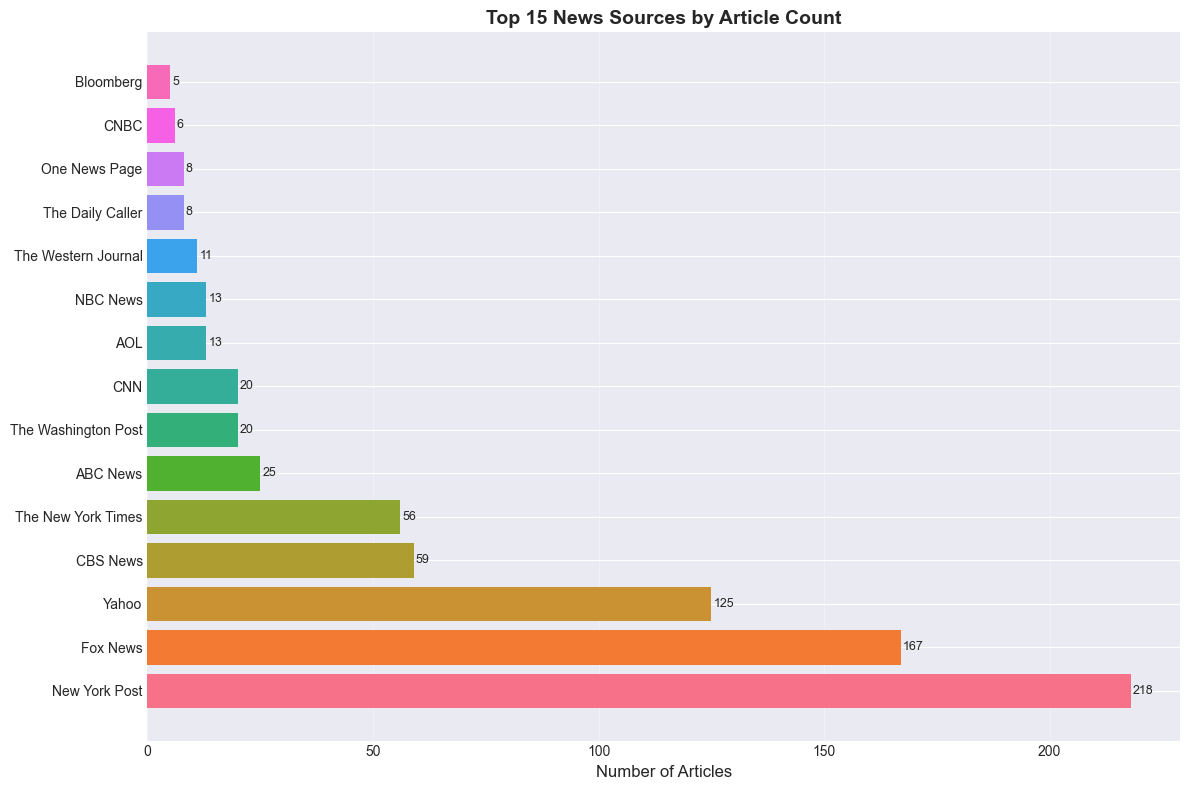

Total unique sources: 60

Top 10 sources:
  New York Post: 218
  Fox News: 167
  Yahoo: 125
  CBS News: 59
  The New York Times: 56
  ABC News: 25
  The Washington Post: 20
  CNN: 20
  AOL: 13
  NBC News: 13


In [12]:
# Count articles by source
source_counts = df['source'].value_counts().head(15)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(source_counts.index, source_counts.values, color=sns.color_palette("husl", len(source_counts)))
ax.set_xlabel('Number of Articles', fontsize=12)
ax.set_title('Top 15 News Sources by Article Count', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(source_counts.values):
    ax.text(v + 0.5, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"Total unique sources: {df['source'].nunique()}")
print(f"\nTop 10 sources:")
for source, count in source_counts.head(10).items():
    print(f"  {source}: {count}")


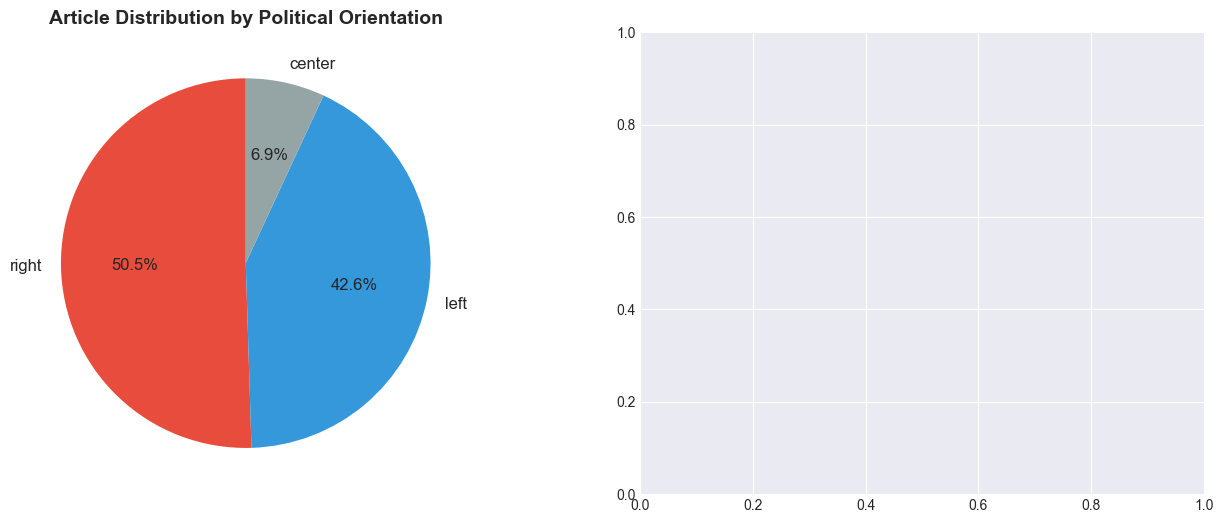

In [13]:
# Check if political_orientation column exists
if 'political_orientation' not in df.columns:
    print("Warning: 'political_orientation' column not found in the data.")
    print("Available columns:", df.columns.tolist())
else:
    # Count articles by political orientation
    orientation_counts = df['political_orientation'].value_counts()
    
    # Create visualizations
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Pie chart with custom colors
    orientation_colors = {'left': '#3498db', 'right': '#e74c3c', 'center': '#95a5a6'}
    colors_list = [orientation_colors.get(o, '#9b59b6') for o in orientation_counts.index]
    ax1.pie(orientation_counts.values, labels=orientation_counts.index, autopct='%1.1f%%',
            startangle=90, colors=colors_list, textprops={'fontsize': 12})
    ax1.set_title('Article Distribution by Political Orientation', fontsize=14, fontweight='bold')
    
  


sentiment              Negative  Neutral  Positive
political_orientation                             
left                         47      201        97
center                       22       18        16
right                       201      168        40


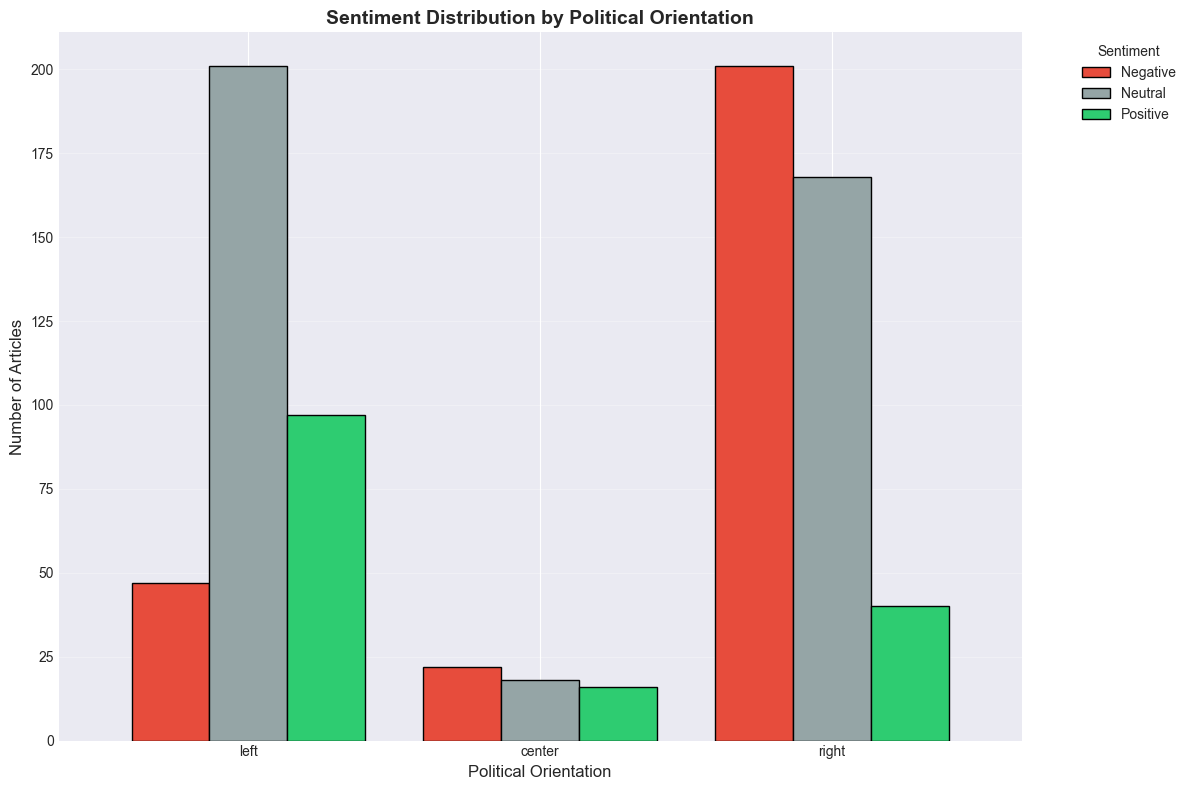

Sentiment by political orientation:
sentiment              Negative  Neutral  Positive
political_orientation                             
left                         47      201        97
center                       22       18        16
right                       201      168        40


In [27]:
# Sentiment distribution by political orientation
if 'political_orientation' in df.columns:
    df['political_orientation'] = pd.Categorical(
        df['political_orientation'],
        categories=['left', 'center', 'right'],
        ordered=True
    )
    orientation_sentiment = pd.crosstab(df['political_orientation'], df['sentiment'])
    print(orientation_sentiment)


    
    # Create grouped bar chart
    fig, ax = plt.subplots(figsize=(12, 8))
    orientation_sentiment.plot(kind='bar', ax=ax, 
                              color=[sentiment_colors.get(s, '#3498db') for s in orientation_sentiment.columns],
                              width=0.8, edgecolor='black')
    ax.set_xlabel('Political Orientation', fontsize=12)
    ax.set_ylabel('Number of Articles', fontsize=12)
    ax.set_title('Sentiment Distribution by Political Orientation', fontsize=14, fontweight='bold')
    ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()
    
    print("Sentiment by political orientation:")
    print(orientation_sentiment)


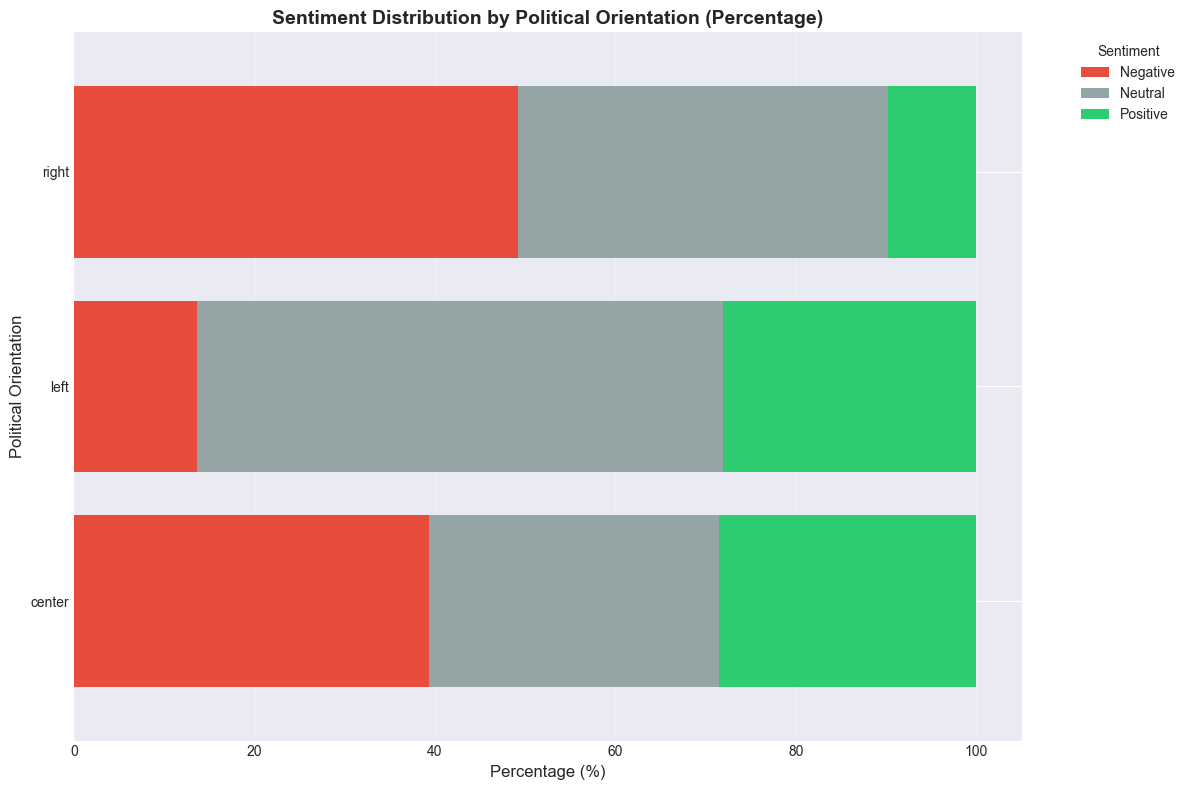

In [15]:
# Sentiment percentage by political orientation
if 'political_orientation' in df.columns:
    orientation_sentiment_pct = orientation_sentiment.div(orientation_sentiment.sum(axis=1), axis=0) * 100
    
    # Create stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 8))
    orientation_sentiment_pct.plot(kind='barh', stacked=True, ax=ax, 
                                   color=[sentiment_colors.get(s, '#3498db') for s in orientation_sentiment_pct.columns],
                                   width=0.8)
    ax.set_xlabel('Percentage (%)', fontsize=12)
    ax.set_ylabel('Political Orientation', fontsize=12)
    ax.set_title('Sentiment Distribution by Political Orientation (Percentage)', fontsize=14, fontweight='bold')
    ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='x')
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()


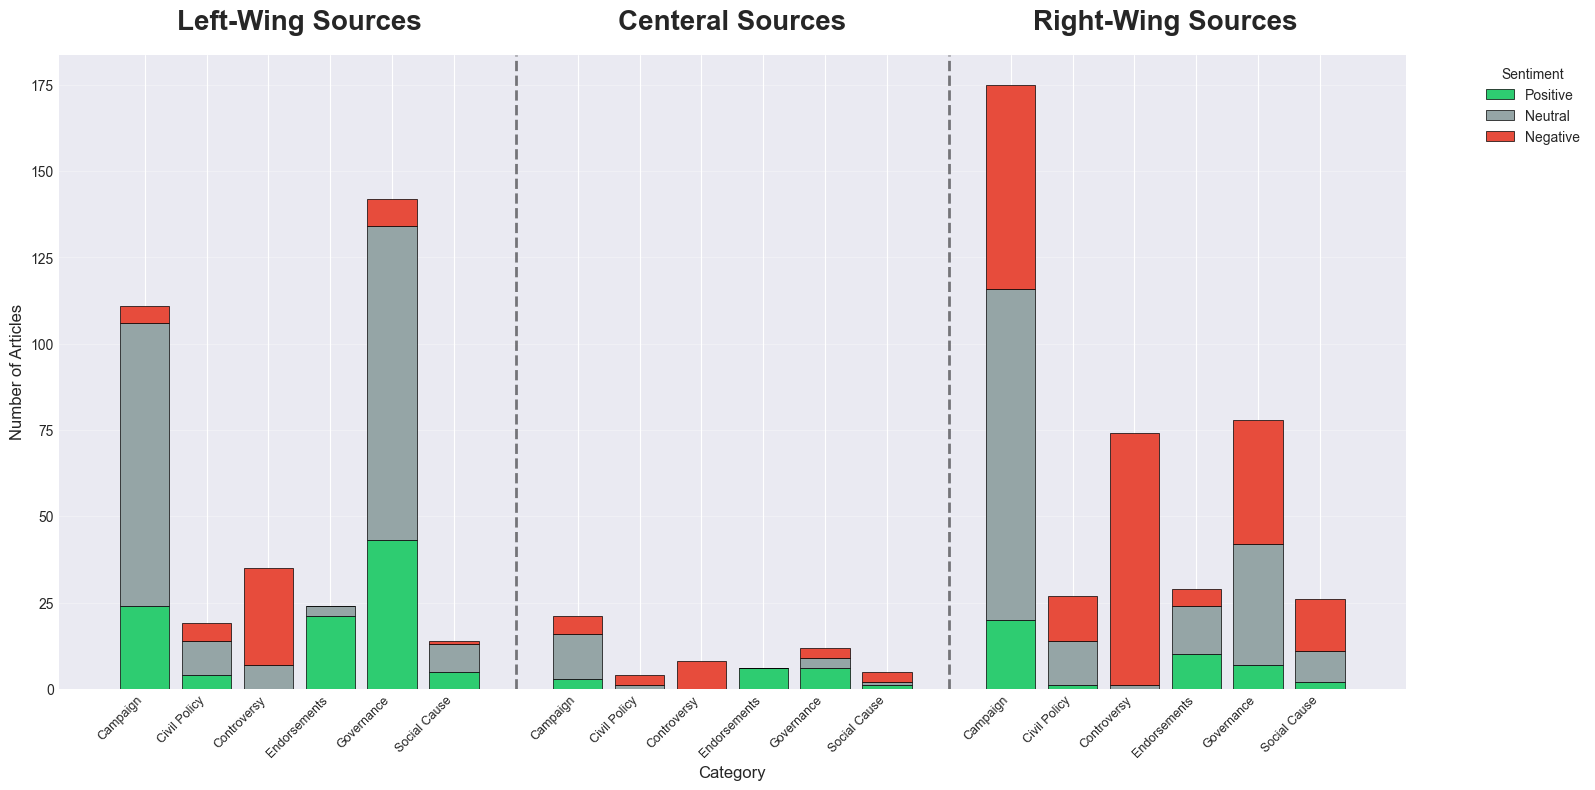

In [16]:
# Category distribution by political orientation (with sentiment)
if 'political_orientation' in df.columns and 'sentiment' in df.columns:
    # Create a stacked bar chart showing categories by political orientation, with sentiment breakdown
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Create pivot table: political_orientation × categories, with sentiment as stacked values
    pivot_data = df.groupby(['political_orientation', 'categories', 'sentiment']).size().unstack(fill_value=0)
    
    # Color scheme for sentiments
    sentiment_colors = {
        'Positive': '#2ecc71',  # Green
        'Negative': '#e74c3c',  # Red
        'Neutral': '#95a5a6'    # Gray
    }
    
    # Get unique political orientations and categories
    orientations = df['political_orientation'].unique()
    categories = df['categories'].unique()
    
    # Create custom x positions with spacing between political orientations
    x_positions = []
    x_labels = []
    current_pos = 0
    spacing = 1  # Space between political orientation groups
    
    for orientation in ["Left", "Center", "Right"]:
        for category in sorted(categories):
            x_positions.append(current_pos)
            x_labels.append(f'{category}')
            current_pos += 1
        current_pos += spacing  # Add spacing after each political orientation group
    
    # Plot bars manually to control spacing
    bottom = np.zeros(len(x_positions))
    bar_width = 0.8
    
    for sentiment in ['Positive', 'Neutral', 'Negative']:  # Order: positive on bottom, negative on top
        values = []
        for orientation in ["left", "center", "right"]:
            for category in sorted(categories):
                try:
                    value = pivot_data.loc[(orientation, category), sentiment]
                except KeyError:
                    value = 0
                values.append(value)
        
        ax.bar(x_positions, values, bar_width, bottom=bottom, 
               label=sentiment, color=sentiment_colors.get(sentiment, '#3498db'),
               edgecolor='black', linewidth=0.5)
        bottom += values
    
    # Add vertical lines to separate political orientations
    separator_pos = 0
    for i, orientation in enumerate(sorted(orientations)):
        separator_pos += len(categories)
        if i < len(orientations) - 1:  # Don't draw line after last group
            ax.axvline(x=separator_pos - 0.5 + spacing/2, color='black', linestyle='--', linewidth=2, alpha=0.5)
        separator_pos += spacing

    group_centers = []
    start = 0
    for orientation in ["Left", "Center", "Right"]:
        center = start + (len(categories) - 1) / 2
        group_centers.append(center)
        start += len(categories) + spacing

    for center, label in zip(group_centers, ["Left-Wing Sources", "Centeral Sources", "Right-Wing Sources"]):
        ax.text(center, ax.get_ylim()[1] * 1.03, label,
                ha='center', va='bottom',
                fontsize=20, fontweight='bold')
    
    ax.set_xlabel('Category', fontsize=12)
    ax.set_ylabel('Number of Articles', fontsize=12)
    ax.set_xticks(x_positions)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=9)
    ax.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    


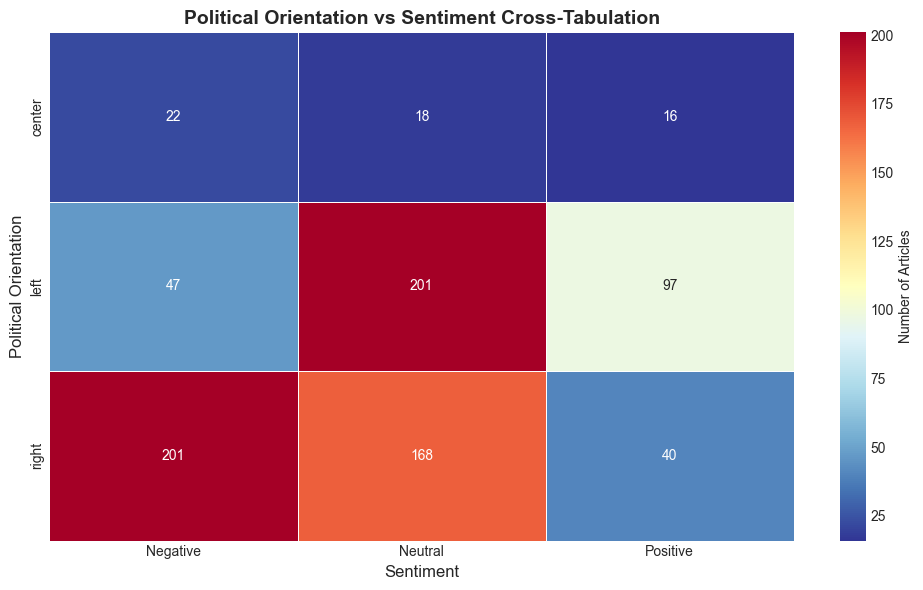

In [17]:
# Heatmap: Political Orientation vs Sentiment
if 'political_orientation' in df.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(orientation_sentiment, annot=True, fmt='d', cmap='RdYlBu_r', ax=ax, 
                cbar_kws={'label': 'Number of Articles'}, linewidths=0.5)
    ax.set_xlabel('Sentiment', fontsize=12)
    ax.set_ylabel('Political Orientation', fontsize=12)
    ax.set_title('Political Orientation vs Sentiment Cross-Tabulation', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
